In [10]:
import pickle
import itertools

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

In [12]:
run_name = "minmax_95_5_prank_3"
with open(f"data/eda_results/eda_human_{run_name}.pkl", "rb") as f:
    results = pickle.load(f)
pf = results["converged_pf_table"][-1]

In [13]:
pca = PCA(n_components=5)
pca.fit(pf)
print(pca.explained_variance_ratio_)

scores = pca.transform(pf)
pf_reconstructed = pca.inverse_transform(scores)
errors = np.linalg.norm(pf - pf_reconstructed, axis=1)
print(errors.mean())

relative_error = (
    np.linalg.norm(pf - pf_reconstructed, axis=1)
    / np.linalg.norm(pf, axis=1)
)
print(relative_error.mean())

[0.3830678  0.28329343 0.22622201 0.10045794 0.00695882]
3.309457029699827e-14
1.621900151699923e-16


In [14]:
pca.components_

array([[-0.5203799 , -0.20202786, -0.38506953,  0.60822857,  0.41251541],
       [ 0.35470679, -0.03850693, -0.54082935, -0.46229763,  0.6053799 ],
       [-0.53812552,  0.75392827,  0.08663772, -0.29908748,  0.2122585 ],
       [-0.18611652, -0.44403853,  0.6750628 , -0.22608034,  0.51124195],
       [ 0.52836485,  0.43831942,  0.30985352,  0.52514118,  0.39613661]])

In [8]:
X_train, X_test = train_test_split(
    pf,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pca = PCA(n_components=4)
pca.fit(X_train)

X_train_hat = pca.inverse_transform(
    pca.transform(X_train)
)
X_test_hat = pca.inverse_transform(
    pca.transform(X_test)
)
train_error = np.mean(
    np.linalg.norm(
        X_train - X_train_hat,
        axis=1
    )
)
test_error = np.mean(
    np.linalg.norm(
        X_test - X_test_hat,
        axis=1
    )
)
print("Train error:", train_error)
print("Test error:", test_error)

relative_train = np.mean(
    np.linalg.norm(X_train - X_train_hat, axis=1)
    / np.linalg.norm(X_train, axis=1)
)

relative_test = np.mean(
    np.linalg.norm(X_test - X_test_hat, axis=1)
    / np.linalg.norm(X_test, axis=1)
)

print(relative_train)
print(relative_test)

Train error: 0.14018472873406546
Test error: 0.15747968790773548
0.07438839098608624
0.07921485386647868


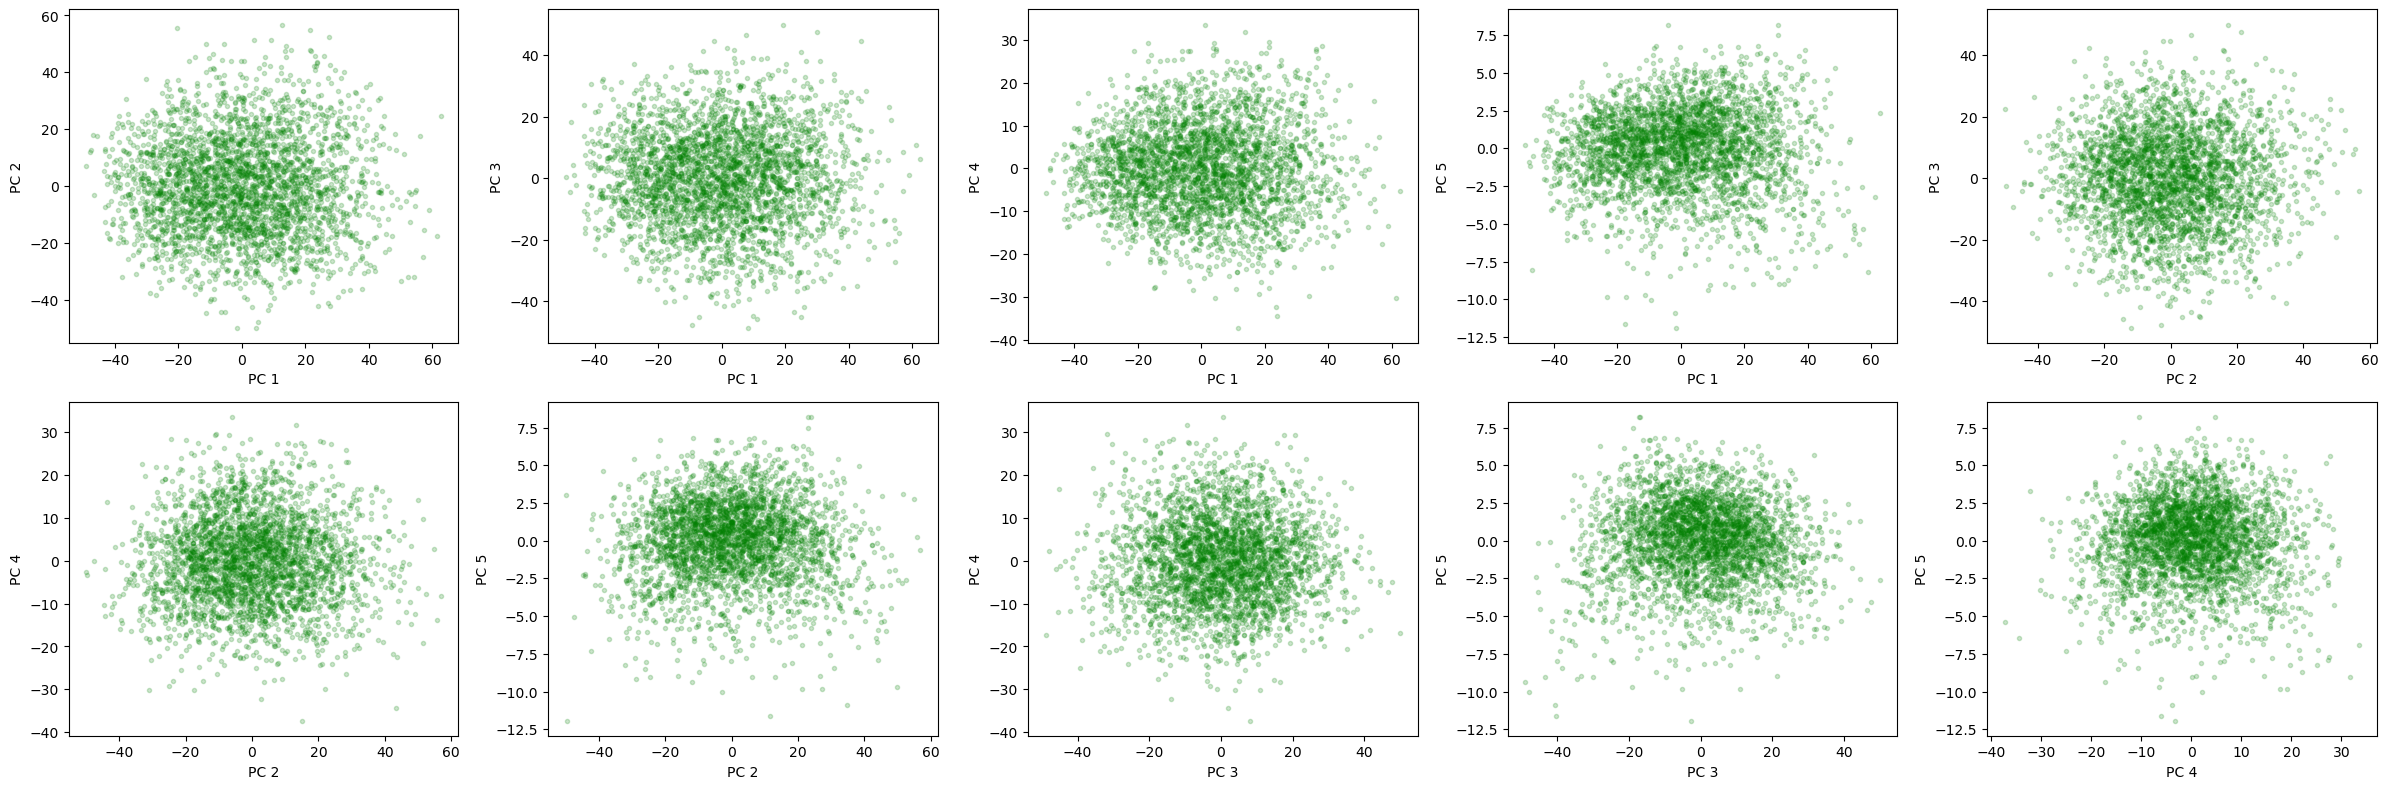

In [15]:
objective_pairs = list(itertools.combinations(range(5), 2)) 
fig, axes = plt.subplots(2, 5, figsize=(24, 8))
axes = axes.ravel()
for ax, (a, b) in zip(axes, objective_pairs):
    ax.plot(scores[:, a], scores[:, b], "go", alpha=0.2, markersize=3, label="PF")
    ax.set_xlabel(f"PC {a + 1}")
    ax.set_ylabel(f"PC {b + 1}")
    
fig.tight_layout()
plt.show()